<a href="https://www.kaggle.com/code/toufiqueeamam18/mlb-2-class-7-assignment?scriptVersionId=350786208" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shree1992/housedata/output.csv
/kaggle/input/datasets/shree1992/housedata/data.csv
/kaggle/input/datasets/shree1992/housedata/data.dat
/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv
/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_train.csv
/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_test.csv
/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv
/kaggle/input/datasets/zerotrace11/tech-company-dataset/tech_company_employee_data_1000.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
uci = pd.read_csv('/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_train.csv')
diabetes = pd.read_csv('/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv')
titanic = pd.read_csv('/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv')
house = pd.read_csv('/kaggle/input/datasets/shree1992/housedata/data.csv')

# impute missing values of occupation column of uci dataset

In [4]:
uci.isnull().sum()

Age                  0
Workclass         1836
fnlwgt               0
Education            0
Education_Num        0
Martial_Status       0
Occupation        1843
Relationship         0
Race                 0
Sex                  0
Capital_Gain         0
Capital_Loss         0
Hours_per_week       0
Country            583
Target               0
dtype: int64

In [5]:
uci["Occupation"].value_counts()

Occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

<Axes: xlabel='Occupation', ylabel='count'>

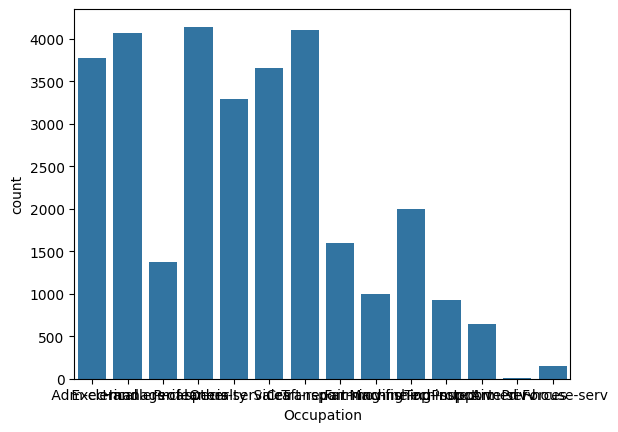

In [6]:
sns.countplot(data=uci, x="Occupation")

In [7]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')

uci['Occupation_simple'] = imputer.fit_transform(
    uci[['Occupation']]
).ravel()

uci[uci["Occupation"].isnull()][
    ["Occupation", "Occupation_simple"]
].head(20)

,Occupation,Occupation_simple
27,NaN,Prof-specialty
61,NaN,Prof-specialty
69,NaN,Prof-specialty
77,NaN,Prof-specialty
106,NaN,Prof-specialty
128,NaN,Prof-specialty
149,NaN,Prof-specialty
154,NaN,Prof-specialty
160,NaN,Prof-specialty
187,NaN,Prof-specialty


In [8]:
uci['Occupation_simple'].isnull().sum()

np.int64(0)

<Axes: xlabel='Occupation', ylabel='count'>

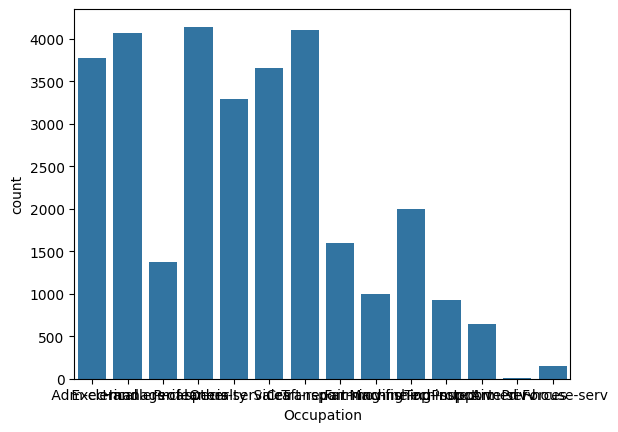

In [9]:
sns.countplot(data=uci, x="Occupation")

<Axes: xlabel='Occupation_simple', ylabel='count'>

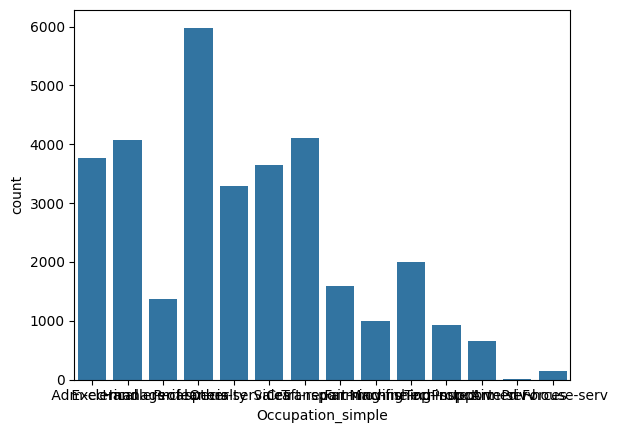

In [10]:
sns.countplot(data=uci, x="Occupation_simple")

# Outliers

# 1. find and mitigate(trimming and capping both) outliers on age column of diabetes dataset

In [11]:
diabetes

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


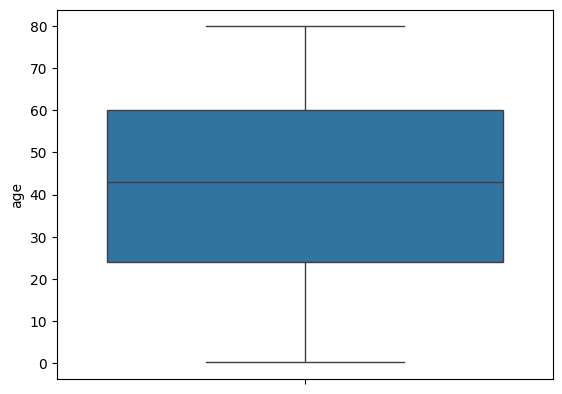

In [12]:
sns.boxplot(diabetes['age'])
plt.show()

In [13]:
diabetes['age'].describe()

count    100000.000000
mean         41.885856
std          22.516840
min           0.080000
25%          24.000000
50%          43.000000
75%          60.000000
max          80.000000
Name: age, dtype: float64

In [14]:
prec25 = diabetes['age'].quantile(0.25)
prec75 = diabetes['age'].quantile(0.75)

print("25th percentile, Q1: ",prec25)
print("75th percentile, Q3: ",prec75)

25th percentile, Q1:  24.0
75th percentile, Q3:  60.0


In [15]:
IQR = prec75 - prec25
IQR

np.float64(36.0)

In [16]:
upper_limit = prec75 + 1.5 * IQR
lower_limit = max(prec25 - 1.5 * IQR, 0)

print("Upper limit: ",upper_limit)
print("Lower limit: ",lower_limit)

Upper limit:  114.0
Lower limit:  0


In [17]:
diabetes[diabetes['age'] > upper_limit]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes


In [18]:
diabetes[diabetes['age'] < lower_limit]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes


trimming

In [19]:
diabetes.shape

(100000, 9)

In [20]:
new_dia = diabetes[(diabetes['age'] < upper_limit) & (diabetes['age'] > lower_limit)]
new_dia.shape

(100000, 9)

In [21]:
new_df_cap = diabetes.copy()

new_df_cap['age'] = np.where(new_df_cap['age'] > upper_limit, upper_limit,np.where(new_df_cap['age']< lower_limit, lower_limit, new_df_cap['age']))

In [22]:
new_df_cap.shape

(100000, 9)

No outliers were detected in the age column

# 2. find and mitigate(trimming and capping both) outliers on price column of house dataset

In [23]:
house

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


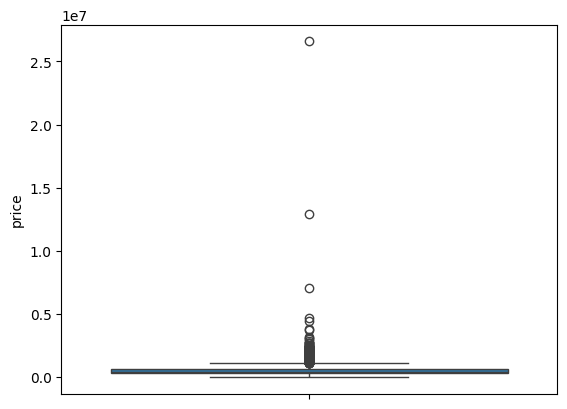

In [24]:
sns.boxplot(house['price'])
plt.show()

In [25]:
house['price'].describe()

count    4.600000e+03
mean     5.519630e+05
std      5.638347e+05
min      0.000000e+00
25%      3.228750e+05
50%      4.609435e+05
75%      6.549625e+05
max      2.659000e+07
Name: price, dtype: float64

In [26]:
prec25 = house['price'].quantile(0.25)
prec75 = house['price'].quantile(0.75)

print("25th percentile, Q1: ",prec25)
print("75th percentile, Q3: ",prec75)

25th percentile, Q1:  322875.0
75th percentile, Q3:  654962.5


In [27]:
IQR = prec75 - prec25
IQR

np.float64(332087.5)

In [28]:
upper_limit = prec75 + 1.5 * IQR
#lower_limit = prec25 - 1.5 * IQR
lower_limit = max(prec25 - 1.5 * IQR, 0)


print("Upper limit: ",upper_limit)
print("Lower limit: ",lower_limit)

Upper limit:  1153093.75
Lower limit:  0


In [29]:
house[house['price'] > upper_limit]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
11,2014-05-02 00:00:00,1.400000e+06,4.0,2.50,2920,4000,1.5,0,0,5,1910,1010,1909,1988,3838-4098 44th Ave NE,Seattle,WA 98105,USA
14,2014-05-02 00:00:00,1.200000e+06,5.0,2.75,2910,9480,1.5,0,0,3,2910,0,1939,1969,3534 46th Ave NE,Seattle,WA 98105,USA
99,2014-05-05 00:00:00,1.395000e+06,5.0,3.50,4010,8510,2.0,0,1,5,2850,1160,1971,0,3930 NE Belvoir Pl,Seattle,WA 98105,USA
122,2014-05-05 00:00:00,2.280000e+06,7.0,8.00,13540,307752,3.0,0,4,3,9410,4130,1999,0,26408 NE 70th St,Redmond,WA 98053,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4348,2014-05-05 00:00:00,2.199900e+06,4.0,1.50,1120,5427,1.0,0,0,3,1120,0,1969,2014,19009-19021 SE 266th St,Covington,WA 98042,USA
4350,2014-07-03 00:00:00,2.659000e+07,3.0,2.00,1180,7793,1.0,0,0,4,1180,0,1992,0,12005 SE 219th Ct,Kent,WA 98031,USA
4465,2014-06-05 00:00:00,2.560498e+06,3.0,2.50,1710,1664,2.0,0,0,5,1300,410,2003,0,2826 21st Ave W,Seattle,WA 98199,USA
4467,2014-06-06 00:00:00,1.337044e+06,4.0,3.50,4280,9583,2.0,0,0,3,4280,0,2005,0,1415 108th Ave SE,Bellevue,WA 98004,USA


In [30]:
house[house['price'] < lower_limit]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country


trimming

In [31]:
house.shape

(4600, 18)

In [32]:
new_house = house[(house['price'] < upper_limit) & (house['price'] > lower_limit)]
new_house.shape

(4311, 18)

capping

In [33]:
new_df_house = house.copy()

new_df_house['price'] = np.where(new_df_house['price'] > upper_limit, upper_limit,np.where(new_df_house['price']< lower_limit, lower_limit, new_df_house['price']))

In [34]:
new_df_house.shape

(4600, 18)

<Axes: ylabel='price'>

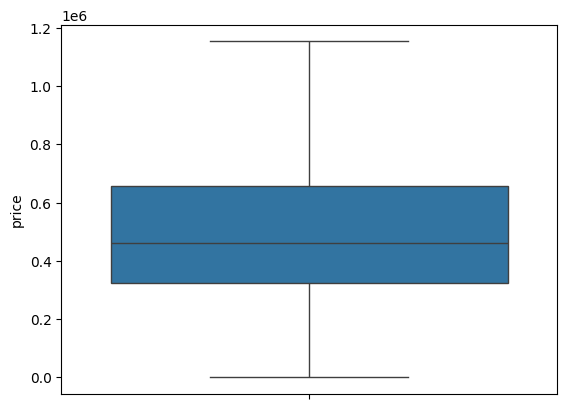

In [35]:
sns.boxplot(new_df_house['price'])